Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-01-30 (+15 weeks)
Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)
Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 1])
➡️  Ground truth shape: torch.Size([38, 1])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=(38, 3, 12), y=(38, 1), edge_index=(2, 210), edge_weight=(210,))
Epoch 1 train loss: 0.7507, val loss: 1.4290 ✓ (new best)
Epoch 2 train loss: 0.6552, val loss: 0.9985 ✓ (new best)
Epoch 3 train loss: 0.5833, val loss: 0.7001 ✓ (new best)
Epoch 4 train loss: 0.5335, val loss: 0.5820 ✓ (new best)
Epoch 5 train loss: 0.5066, val loss: 0.5141 ✓ (new best)
Epoch 6 train loss: 0.4898, val loss: 0.4824 ✓ (new best)
Epoch 7 train loss: 0.4612, val loss: 0.4562 ✓ (new best)
Epoch 8 train loss: 0.4569, val loss: 0.4

/home/de-schrijvers/projects/germany_gnn/src/models/_deepmodel.py:467: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


ValueError: All arrays must be of the same length

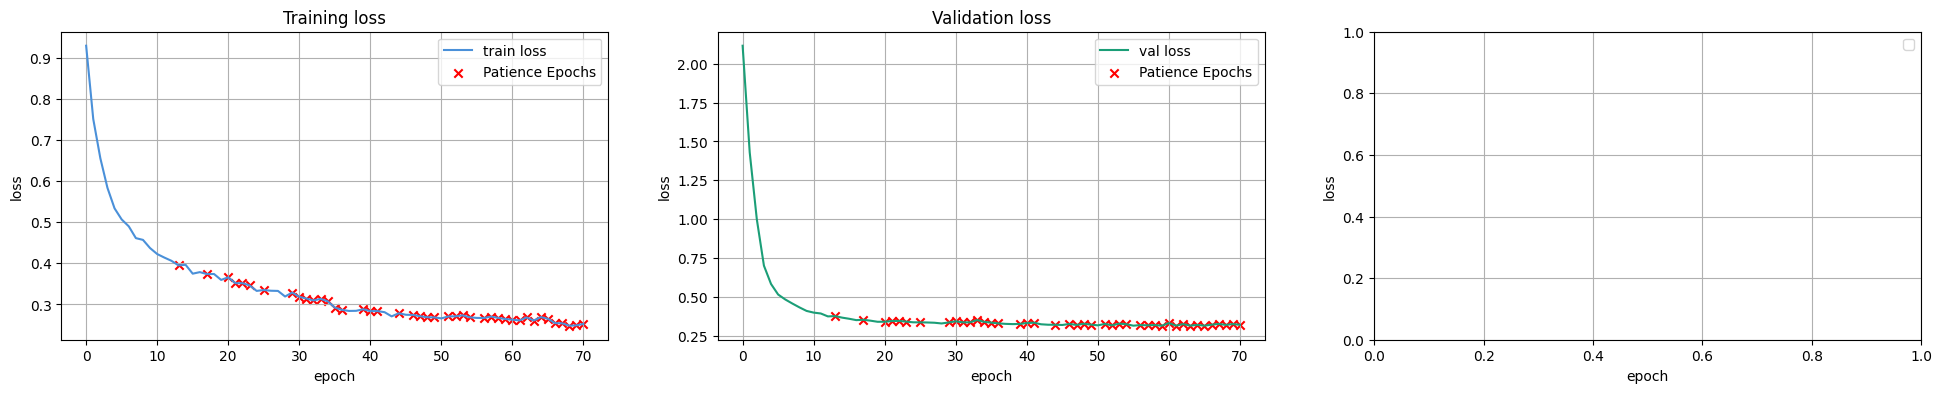

In [2]:
from src.configmanager.experimentconfigmanager import ExperimentConfigManager

n_epochs = 100
lr       = 0.000075
min_delta = 0.001
loss = 'mse'



global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  : {'mode': 'min', 'factor': 0.5, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss
    }

experiment1 = ExperimentConfigManager()
experiment1.define(experiment_name = 'trial', 
                   disease_name    = 'influenza',
                   model           = 'tgcn', 
                   min_date='2006-05-15',
                   max_date= '2020-06-01',
                   global_hparams = global_hparams, 
                   split_trainval= '2018-06-01',
                   split_valtest='2019-06-01',
                   horizon_size = 1,
                   horizon_leadtime = 3,
                   sequence_length=12,
                   lags =  1,
                   train_hparams=    {"verbose": 2},
                   graphs=['boolean_neighbors_selfmn','identity_graph'])
experiment1.execute('trial')
experiment1.save_experiment('trial')


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-01-30 (+15 weeks)
Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)
Dataloader temporal windowing: extending data collection from 2006-01-30 to 2005-10-17 (+15 weeks)


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/home/de-schrijvers/projects/germany_gnn/src/models/weights_manager.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights

✓ Model loaded
Test loss: 0.6015
✓ Model loaded


/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/home/de-schrijvers/projects/germany_gnn/src/models/weights_manager.py:123: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights

Test loss: 0.7258


(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 1'}, ylabel='incidence'>],
       dtype=object))

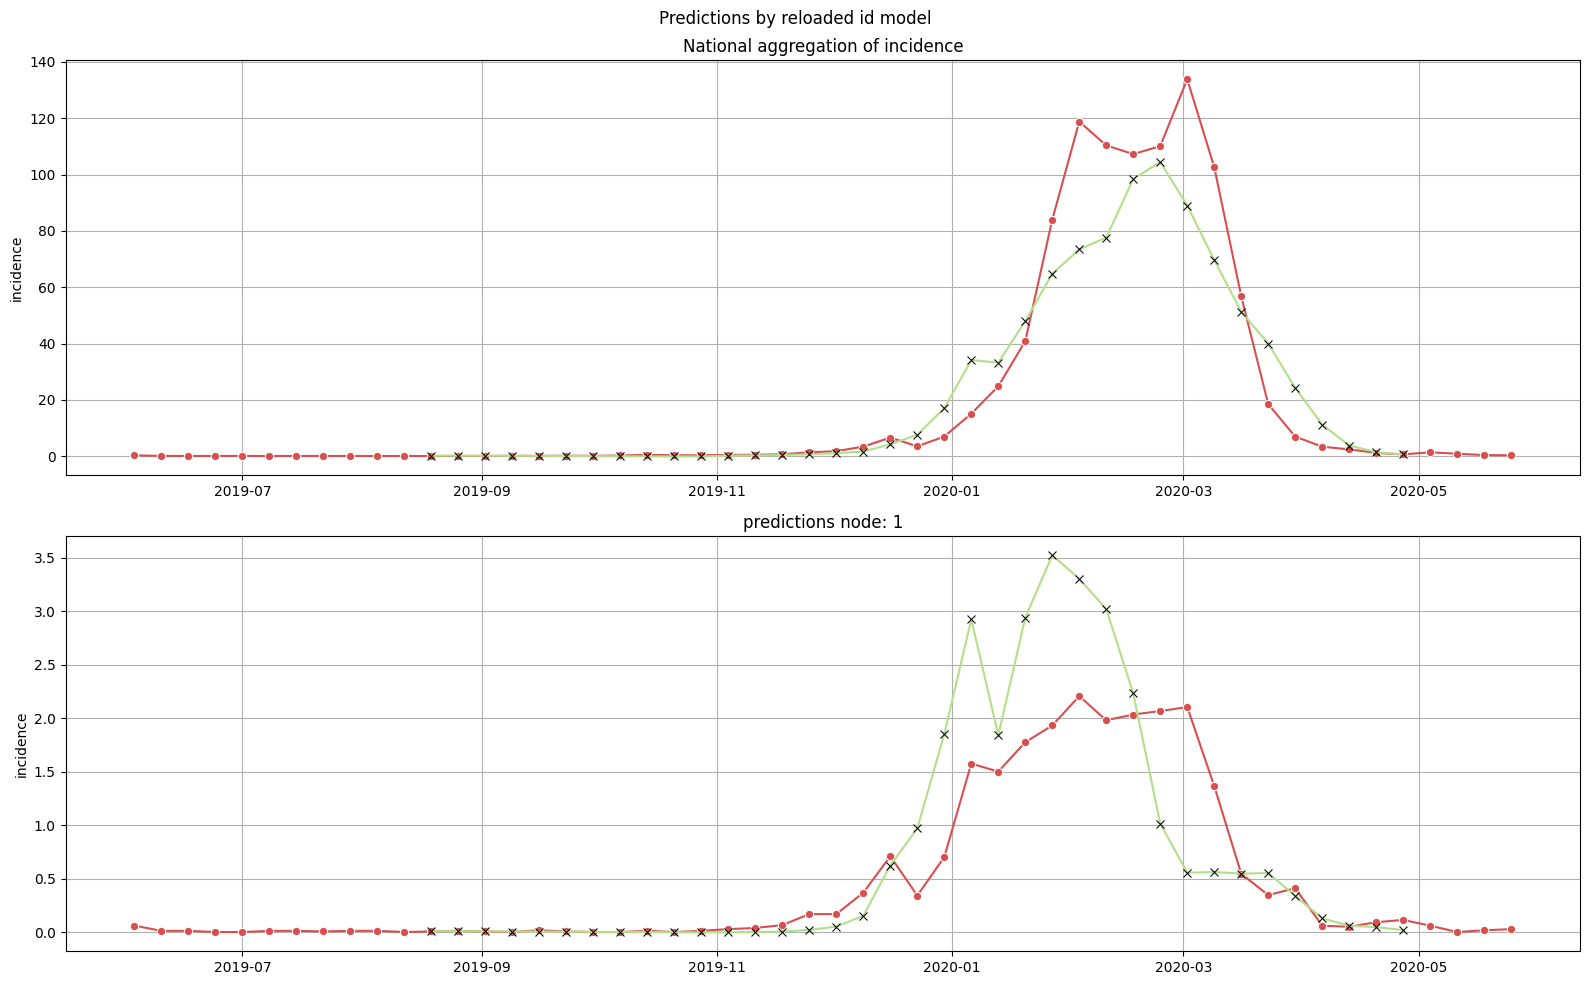

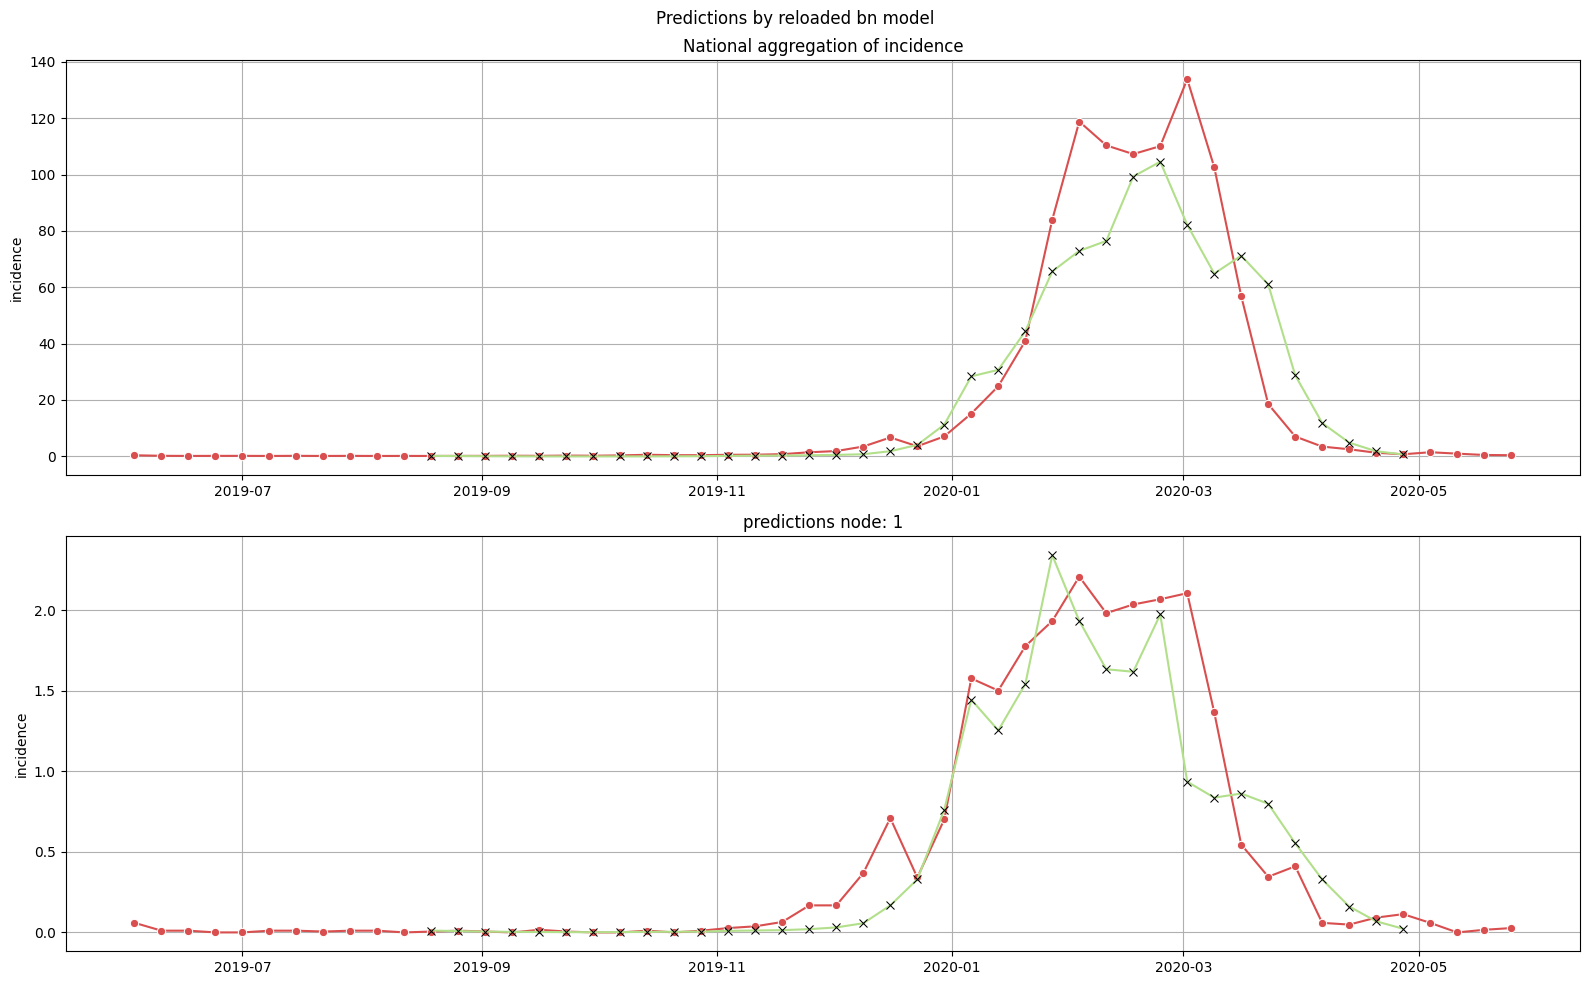

In [10]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils import get_data_env

epidata_nuts2 = GNNDataLoader('influenza', get_data_env(), nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=False, horizon_size = 1, horizon_leadtime = 3, sequence_length=12)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = 1)
epidata_nuts2.finalize()
epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
epidata_nuts2_bn2  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_selfmn').construct_dataloaders()

from src.models.spatiotemporal_baseline import TGCNModel




(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 38'}, ylabel='incidence'>],
       dtype=object))

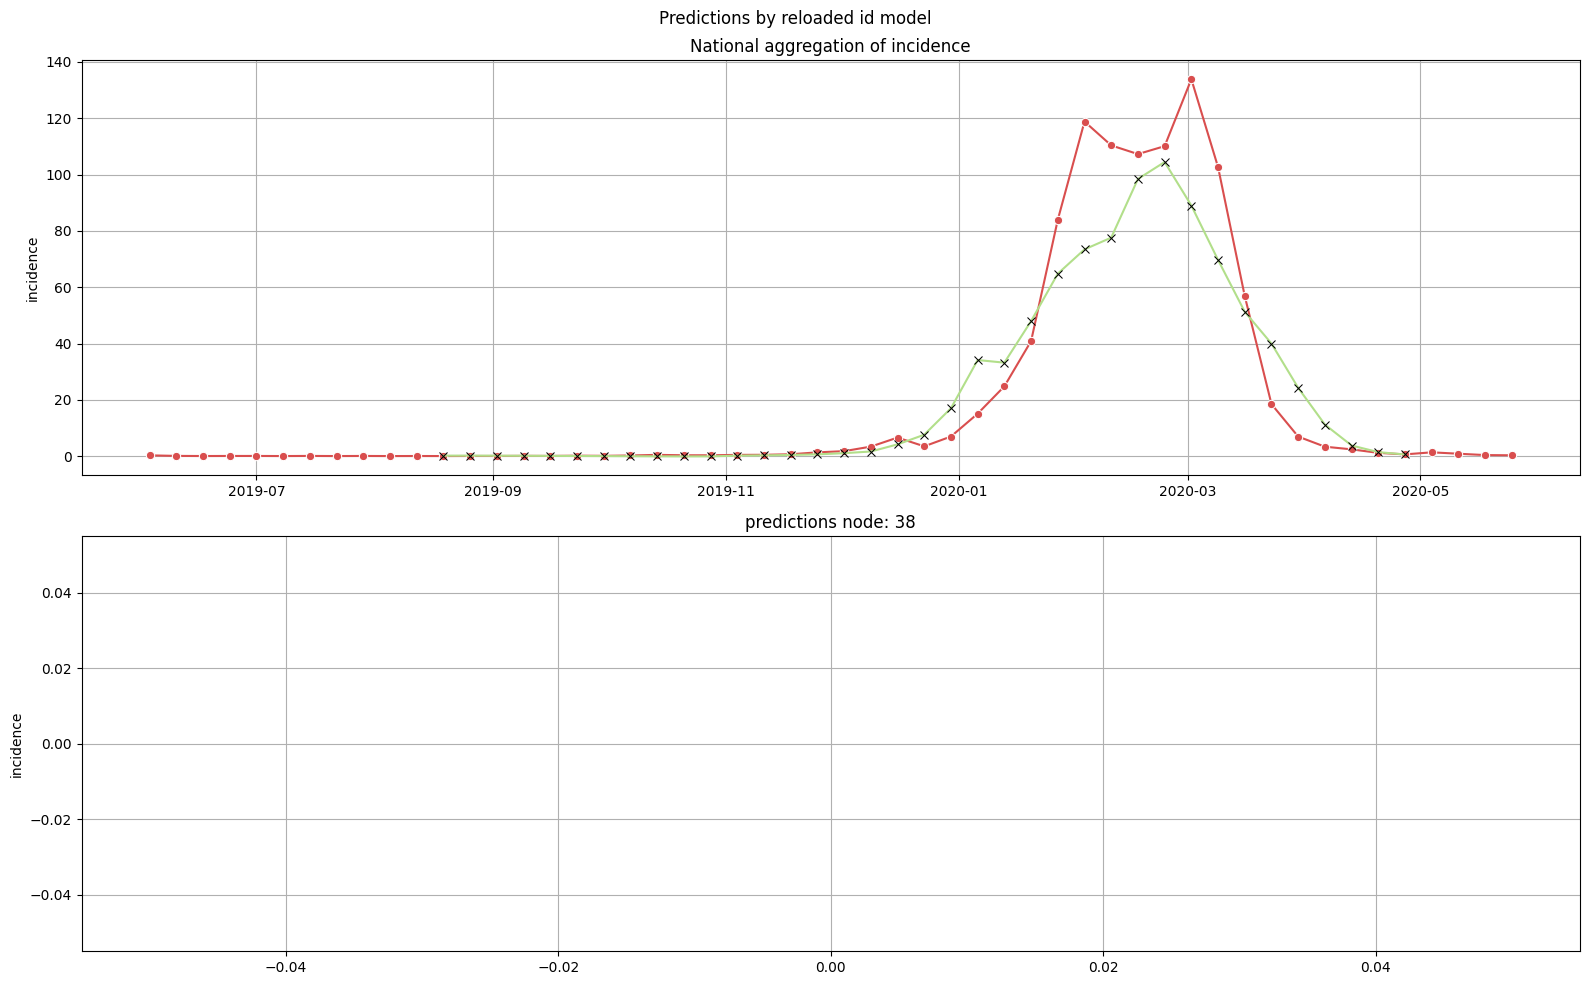

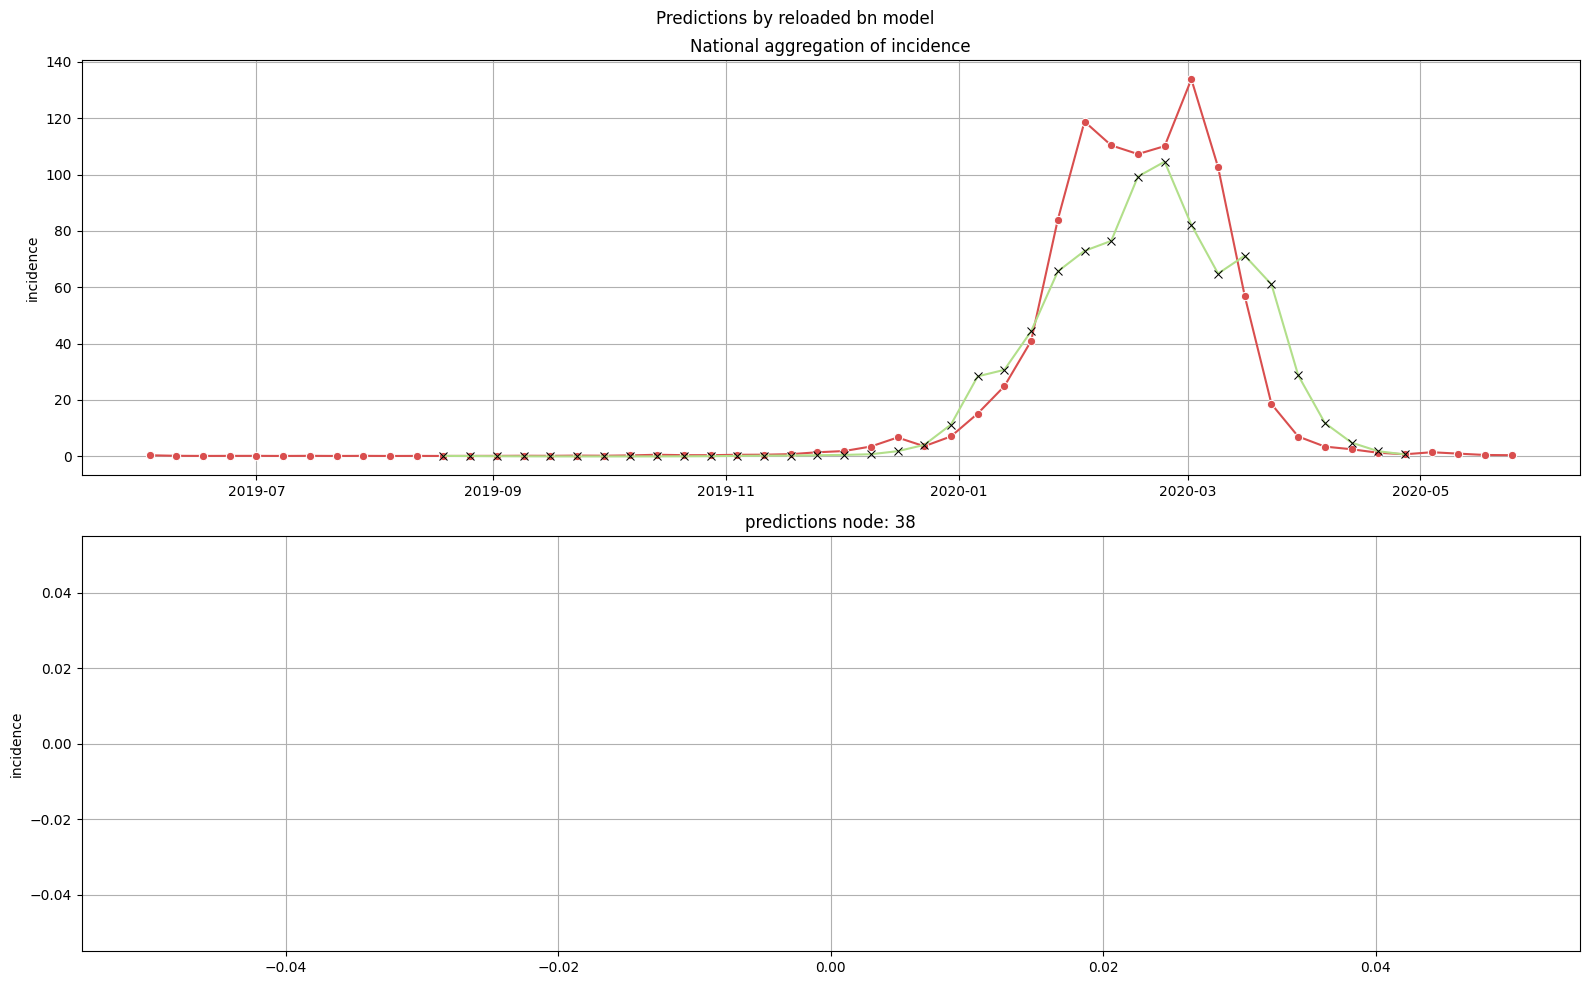

In [49]:
node = 38


# model_id = TGCNModel(dataloader = epidata_nuts2_id, name = "reloaded id model")
# model_id.load_config(model_name='experiment_trial_tgcn_identity_graph')
# model_id.forecast('test')
model_id.show_forecasts('test',node)

# model_bn = TGCNModel(dataloader = epidata_nuts2_bn2, name = "reloaded bn model")
# model_bn.load_config(model_name='experiment_trial_tgcn_boolean_neighbors_selfmn')
# model_bn.forecast('test')
model_bn.show_forecasts('test',node)